In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/cleaned_data.csv")

In [10]:

df['Arrival'] = pd.to_datetime(df['Arrival'], errors='coerce')
df['Departure'] = pd.to_datetime(df['Departure'], errors='coerce')

In [11]:
df['Duration'] = df['Departure'] - df['Arrival']
df['Duration_hours'] = df['Duration'].dt.total_seconds() / 3600
df.dropna(subset=['Duration_hours'], inplace=True)

In [7]:
df = df.rename(columns={'Arrival_time': 'Arrival', 'Departure_Time': 'Departure'})

if 'Duration_hours' not in df.columns:
    df['Arrival'] = pd.to_datetime(df['Arrival'], format='%Y-%m-%d %H:%M:%S')
    df['Departure'] = pd.to_datetime(df['Departure'], format='%Y-%m-%d %H:%M:%S')
    df['Duration'] = df['Departure'] - df['Arrival']
    df['Duration_hours'] = df['Duration'].dt.total_seconds() / 3600

In [12]:
def classify_route(x):
    if x < 2:
        return "Short"
    elif x < 5:
        return "Medium"
    else:
        return "Long"

df['Route_Type'] = df['Duration_hours'].apply(classify_route)

In [13]:
# Task 4.1: Average journey duration
avg_duration = df.groupby('Route_Type')['Duration_hours'].mean()

print("\nAverage Journey Duration (in hours):")
print(avg_duration)


Average Journey Duration (in hours):
Route_Type
Long      13.898344
Medium     3.879048
Short     -0.055336
Name: Duration_hours, dtype: float64


In [17]:
# Task 4.2: High-traffic stations
station_traffic = df['Station_Code'].value_counts()

print("\nTop 5 High-Traffic Stations:")
print(station_traffic.head(5))


Top 5 High-Traffic Stations:
Station_Code
KYN     828
SDAH    745
MSB     738
HWH     699
TNA     493
Name: count, dtype: int64


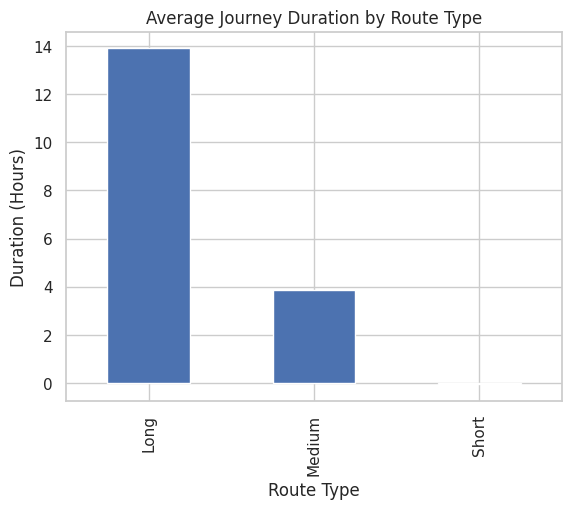

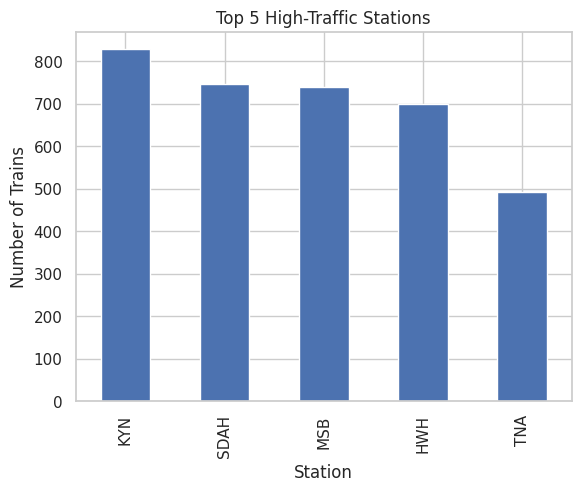

In [18]:
# Task 4.3: Visualizations
sns.set(style="whitegrid")

# Avg duration chart
plt.figure()
avg_duration.plot(kind='bar')
plt.title("Average Journey Duration by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Duration (Hours)")
plt.show()

# Station traffic chart
plt.figure()
station_traffic.head(5).plot(kind='bar')
plt.title("Top 5 High-Traffic Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trains")
plt.show()

In [19]:
# Task 4.4: Key Observations
print("\nKey Observations:")

print("- Long routes have higher journey durations.")
print("- Short routes are faster and frequent.")

top_station = station_traffic.idxmax()
print(f"- {top_station} is the busiest station.")


Key Observations:
- Long routes have higher journey durations.
- Short routes are faster and frequent.
- KYN is the busiest station.
